In [ ]:
import os
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import (make_scorer, matthews_corrcoef, f1_score, 
                             balanced_accuracy_score, precision_score, 
                             recall_score, roc_curve, auc, 
                             precision_recall_curve, average_precision_score, roc_auc_score)


In [ ]:
# 1. Directory
output_dir = 'model_outputs'
os.makedirs(output_dir, exist_ok=True)

# 2. Data loading and splitting
ppi_data = pd.read_csv("ppi.csv")
unique_proteins = ppi_data['uniprot_id'].unique()
train_val_ids, test_ids = train_test_split(unique_proteins, test_size=0.20, random_state=22)
train_ids, val_ids = train_test_split(train_val_ids, test_size=0.25, random_state=23)

train_data = ppi_data[ppi_data['uniprot_id'].isin(train_ids)]
y_train = train_data['p_interface']

# 3. Feature groups
base_pssm  = [c for c in ppi_data.columns if c.startswith("pssm_") and "_wm_" not in c]
base_ss    = ["prob_helix", "prob_sheet", "prob_coil"]
base_surf  = ["normalized_abs_surf_acc", "rel_surf_acc"]
base_hydro = ["normalized_hydropathy_index"]

feature_sets = {
    "Model 0: Base Only": (base_pssm + base_ss + base_surf + base_hydro),
    "Model 1: Evolutionary (PSSM 9wm)": ([c for c in ppi_data.columns if "9_wm_pssm" in c] + base_ss + base_surf + base_hydro),
    "Model 2: Structural (SS 9wm)": ([c for c in ppi_data.columns if "9_wm_prob" in c] + base_pssm + base_surf + base_hydro),
    "Model 3: Exposure (ASA/RSA 9wm)": ([c for c in ppi_data.columns if "9_wm_rel_surf" in c or "9_wm_normalized_abs_surf" in c] + base_pssm + base_ss + base_hydro),
    "Model 4: Chemical (Hydro 9wm)": ([c for c in ppi_data.columns if "9_wm_normalized_hydropathy" in c] + base_pssm + base_ss + base_surf)
}

In [ ]:
# 4. Pipelines
rus = RandomUnderSampler(random_state=33)
xgb_ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])

experiments = [
    ("RF (Undersampled)", Pipeline([
        ('resampler', rus), 
        ('model', RandomForestClassifier(n_estimators=400, max_depth=None, max_features='sqrt', min_samples_split=2, random_state=66, n_jobs=-1))
    ])),
    ("XGBoost (Class Weight)", XGBClassifier(n_estimators=500, learning_rate=0.01, max_depth=10, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=xgb_ratio, eval_metric='logloss', random_state=100, n_jobs=-1))
]

# 5. Metrices
scoring_metrics = {
    'MCC': make_scorer(matthews_corrcoef),
    'F1-Score': make_scorer(f1_score, zero_division=0),
    'ROC-AUC': 'roc_auc',
    'Bal. Accuracy': make_scorer(balanced_accuracy_score),
    'Precision': make_scorer(precision_score, zero_division=0),
    'Recall': make_scorer(recall_score, zero_division=0)
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
final_results = []
saved_files_registry = {} 

Processing Model 0: Base Only...
Done with Model 0: Base Only in 1.21 minutes.
Processing Model 1: Evolutionary (PSSM 9wm)...
Done with Model 1: Evolutionary (PSSM 9wm) in 2.72 minutes.
Processing Model 2: Structural (SS 9wm)...
Done with Model 2: Structural (SS 9wm) in 0.97 minutes.
Processing Model 3: Exposure (ASA/RSA 9wm)...
Done with Model 3: Exposure (ASA/RSA 9wm) in 0.89 minutes.
Processing Model 4: Chemical (Hydro 9wm)...
Done with Model 4: Chemical (Hydro 9wm) in 0.76 minutes.

--- FINAL SUMMARY TABLE ---
                Biological Model                 Config   MCC    F1   AUC  Recall  Precision
              Model 0: Base Only      RF (Undersampled) 0.118 0.253 0.621   0.618      0.159
              Model 0: Base Only XGBoost (Class Weight) 0.095 0.217 0.621   0.261      0.187
Model 1: Evolutionary (PSSM 9wm)      RF (Undersampled) 0.251 0.330 0.769   0.781      0.209
Model 1: Evolutionary (PSSM 9wm) XGBoost (Class Weight) 0.258 0.358 0.766   0.487      0.282
    Model 2: St

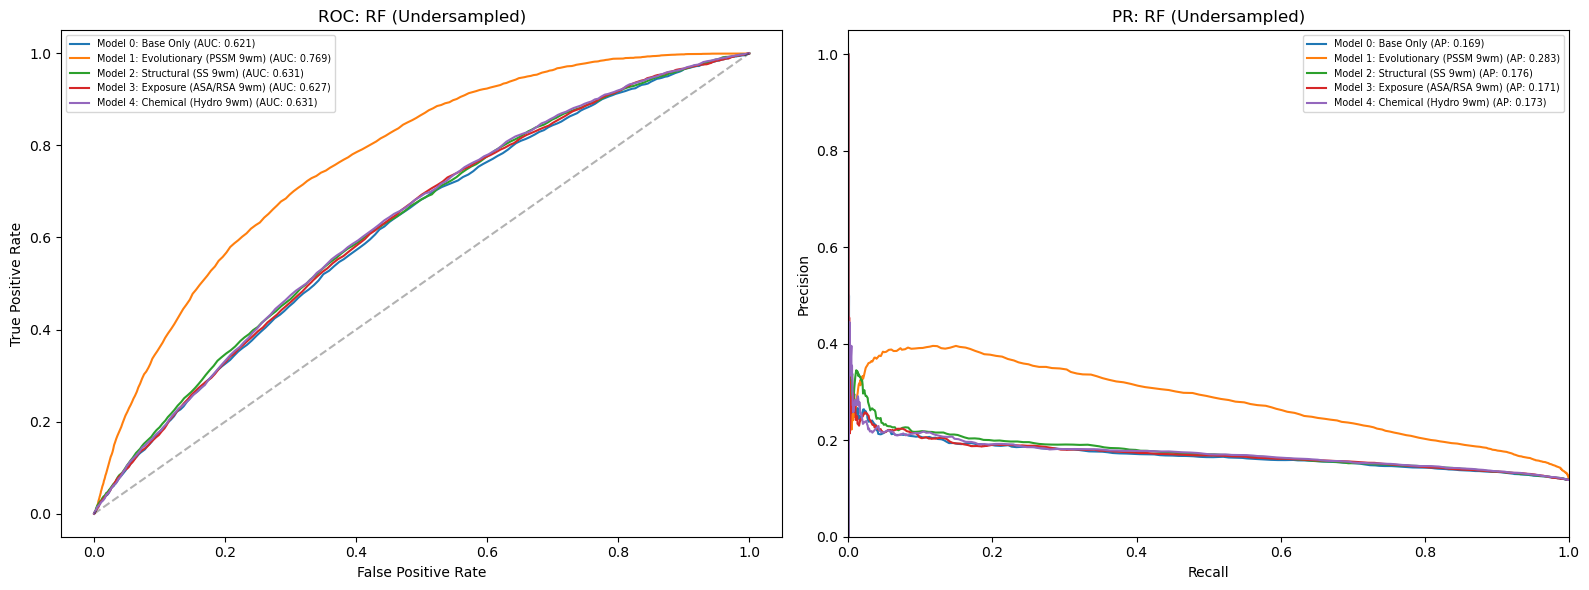

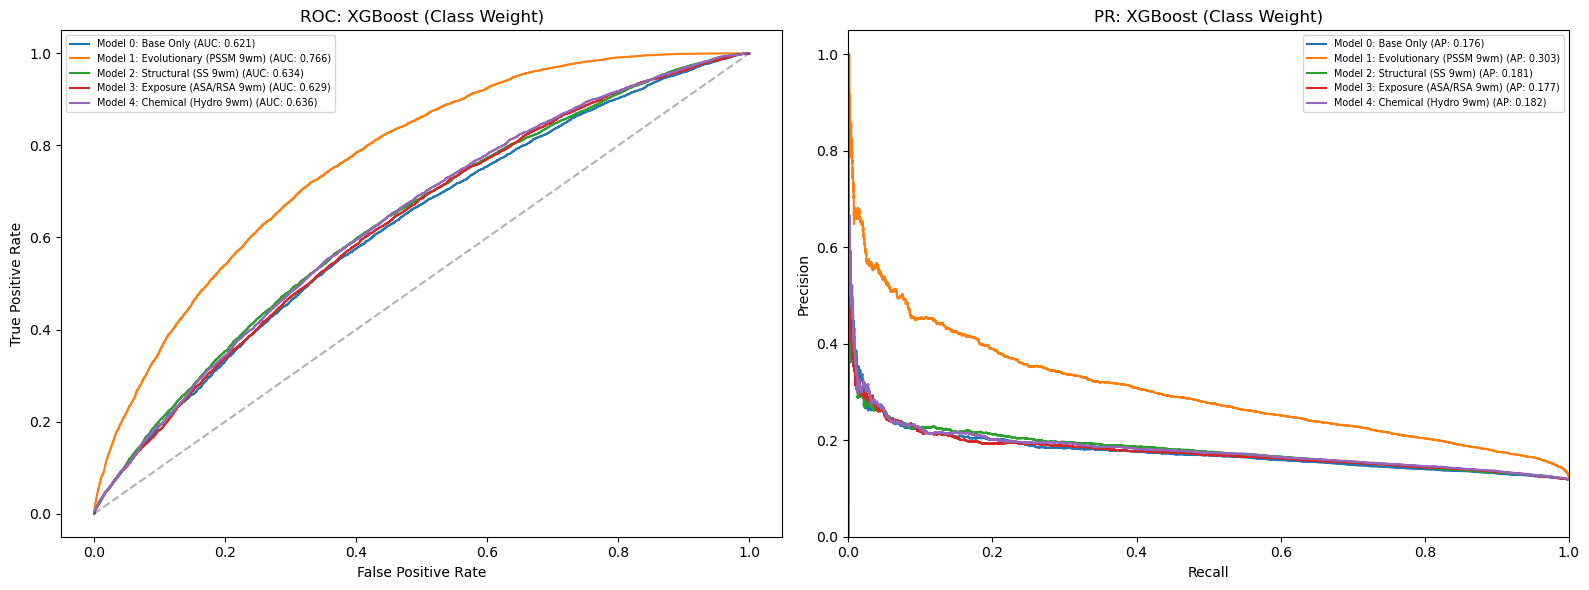


--- DONE: All CSVs saved in 'model_outputs/' ---
                Biological Model                 Config   MCC    F1   AUC  Recall  Precision
              Model 0: Base Only      RF (Undersampled) 0.118 0.253 0.621   0.618      0.159
              Model 0: Base Only XGBoost (Class Weight) 0.095 0.217 0.621   0.261      0.187
Model 1: Evolutionary (PSSM 9wm)      RF (Undersampled) 0.251 0.330 0.769   0.781      0.209
Model 1: Evolutionary (PSSM 9wm) XGBoost (Class Weight) 0.258 0.358 0.766   0.487      0.282
    Model 2: Structural (SS 9wm)      RF (Undersampled) 0.121 0.255 0.631   0.621      0.160
    Model 2: Structural (SS 9wm) XGBoost (Class Weight) 0.109 0.227 0.634   0.262      0.200
 Model 3: Exposure (ASA/RSA 9wm)      RF (Undersampled) 0.122 0.255 0.627   0.625      0.161
 Model 3: Exposure (ASA/RSA 9wm) XGBoost (Class Weight) 0.102 0.224 0.629   0.271      0.191
   Model 4: Chemical (Hydro 9wm)      RF (Undersampled) 0.126 0.257 0.631   0.637      0.161
   Model 4: Chemical

In [ ]:
# 6. Main execution loop

output_dir = 'model_outputs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

final_results = []
saved_files_registry = {} 

for model_label, features in feature_sets.items():
    start_time = time.time()
    print(f"Processing {model_label}...")
    X_sub = train_data[features]
    
    for config_label, clf in experiments:
        # 1. Run CV ONLY ONCE 
        y_probas = cross_val_predict(clf, X_sub, y_train, cv=cv, method='predict_proba', n_jobs=-1)
        probs = y_probas[:, 1]
        preds = (probs >= 0.5).astype(int) # Get binary predictions for MCC/F1
        
        # 2. CLEAN FILENAMES
        safe_model = model_label.replace(" ", "_").replace(":", "").replace("/", "_").replace("(", "").replace(")", "")
        safe_config = config_label.replace(" ", "_").replace("(", "").replace(")", "")
        
        filename = f"{safe_model}_{safe_config}.csv"
        file_path = os.path.join(output_dir, filename)
       
        pd.DataFrame({'y_true': y_train, 'y_prob': probs}).to_csv(file_path, index=False)
        
        if config_label not in saved_files_registry:
            saved_files_registry[config_label] = []
        saved_files_registry[config_label].append((model_label, file_path))
        
        final_results.append({
            'Biological Model': model_label, 
            'Config': config_label,
            'MCC': round(matthews_corrcoef(y_train, preds), 3),
            'F1': round(f1_score(y_train, preds, zero_division=0), 3),
            'AUC': round(roc_auc_score(y_train, probs), 3),
            'Recall': round(recall_score(y_train, preds, zero_division=0), 3),
            'Precision': round(precision_score(y_train, preds, zero_division=0), 3)
        })
    
    elapsed = (time.time() - start_time) / 60
    print(f"Done with {model_label} in {elapsed:.2f} minutes.")

# Summary table
print("\n--- FINAL SUMMARY TABLE ---")
print(pd.DataFrame(final_results).to_string(index=False))

# 7. Visualization
for config_name, file_list in saved_files_registry.items():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    for model_label, path in file_list:
        data = pd.read_csv(path)
        y_true, y_prob = data['y_true'], data['y_prob']

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        ax1.plot(fpr, tpr, label=f'{model_label} (AUC: {auc(fpr, tpr):.3f})')
        
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        ax2.plot(recall, precision, label=f'{model_label} (AP: {average_precision_score(y_true, y_prob):.3f})')

    # ROC Labels
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax1.set_title(f'ROC: {config_name}')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.legend(fontsize='x-small')
    
    # PR Labels
    ax2.set_title(f'PR: {config_name}')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_xlim([0, 1.0])
    ax2.set_ylim([0, 1.05])
    ax2.legend(fontsize='x-small')
    
    plt.tight_layout()
    plt.show()

print("\n--- DONE: All CSVs saved in 'model_outputs/' ---")
print(pd.DataFrame(final_results).to_string(index=False))